In [78]:
import requests
import os
import re
import time
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
load_dotenv()

True

#### Scopus API Search

- Scopus api has 2 views, complete (25 results) and standard (200 results)
- 5000 item total result limit without ‘cursor pagination’
- weekly quota 20000
- requests per sec 9 
- view results fields ![view results][https://dev.elsevier.com/sc_search_views.html]

we can query by publishers
```
'PUBLISHER(Wiley) AND TITLE-ABS(poly*)'
```
As of 15 Jun 26:
- For Wiley: 275551 results
- Springer Nature: 20022 results
- Elsevier: 766550 results

TODO: maybe use the COMPLETE view to retrieve as much abstracts as possible?

In [6]:
def fetch_scopus_year(
    publisher: str,
    pubyear: int,
    count: int = 200
) -> list[dict]:
    """Fetches papers from Scopus for a given publisher and publication year.

    Args:
        publisher (str): The name of the publisher to filter by.
        pubyear (int): The publication year to filter by.
        count (int, optional): The number of results to fetch per request. Defaults to 200.
        query_term (str, optional): The search term to use in the query. Defaults to "poly*".

    Returns:
        list[dict]: A list of dictionaries containing paper information.
    """
    url = "https://api.elsevier.com/content/search/scopus"
    scopus_api_key = os.getenv("SCOPUS_API_KEY")
    query = f'PUBLISHER({publisher}) AND TITLE-ABS(poly*) AND PUBYEAR < {pubyear}'

    # need dc:description for abstract
    FIELDS = "eid,prism:doi,dc:title,prism:publicationName,dc:publisher,openaccess,openaccessFlag"
    # pagination does not need start param
    # check cursor:@next for next page, and cursor:"*" for first page
    params = {
        "query":   query,
        "field":   FIELDS,
        "start":   0,
        "count":   200,
        "view":    "STANDARD",   
        # "cursor": "*",
    }
    headers = {
        "X-ELS-APIKey": scopus_api_key,
        "Accept": "application/json"
    }

    response = requests.get(url, params=params, headers=headers)

    assert response.status_code == 200, f"Request failed, ELS Status: {response.headers.get('X-ELS-Status')}"

    data = response.json()

    entries = data.get("search-results", {}).get("entry", [])

    records = []

    for e in entries:
        records.append({
            "eid": e.get("eid"),
            "doi": e.get("prism:doi"),
            "title": e.get("dc:title"),
            "journal": e.get("prism:publicationName"),
            "publisher": e.get("dc:publisher") or publisher,
            "open_access": e.get("openaccess"),
            "open_access_flag": e.get("openaccessFlag"),
        })

    if not records:
        print(f"No records found for publisher: {publisher}, year: {pubyear}")

    if len(records) < count:
        print(f"Only {len(records)} records found for publisher: {publisher}, year: {pubyear}")

    return records

In [21]:
publisher = "Elsevier"
years = [2026, 2024, 2022, 2020, 2018]

all_records = []

for year in years:
    records = fetch_scopus_year(
        publisher=publisher,
        pubyear=year,
        count=200
    )

    all_records.extend(records)

    time.sleep(0.2)  # Sleep to respect API rate limits

df = pd.DataFrame(all_records)

# Optional deduplication, useful if Scopus returns overlaps
df = df.drop_duplicates(subset=["eid"], keep="first").reset_index(drop=True)

print(f"Total records fetched: {len(df)}")

Total records fetched: 1000


In [22]:
df

,eid,doi,title,journal,publisher,open_access,open_access_flag
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False
...,...,...,...,...,...,...,...
995,2-s2.0-85041994216,10.1016/j.electacta.2017.12.004,Electrochemical determination of luteolin usin...,Electrochimica Acta,Elsevier,0,False
996,2-s2.0-85041013742,10.1016/j.electacta.2017.11.185,Capacity Fading Mechanism in Lithium-Sulfur Ba...,Electrochimica Acta,Elsevier,0,False
997,2-s2.0-85035316380,10.1016/j.electacta.2017.11.133,Superior capacitive properties of polyaniline ...,Electrochimica Acta,Elsevier,0,False
998,2-s2.0-85034993468,10.1016/j.polymer.2017.11.045,Theoretical study on the reaction of maleic an...,Polymer,Elsevier,0,False


In [23]:
output_path = os.path.join("..", "data", f"{publisher}_papers.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

At the moment we have extracted 1000 articles each from 3 publishers. For full extraction I need to implement cursor pagination.

In [28]:
papers = ["elsevier_papers.csv", "springer_nature_papers.csv", "wiley_papers.csv"]
dfs = []
for paper in papers:
    path = os.path.join("..", "data", paper)
    df = pd.read_csv(path, sep="\t")
    dfs.append(df)
    print(f"{paper}: {len(df)} records")

df = pd.concat(dfs, ignore_index=True)

elsevier_papers.csv: 1000 records
springer_nature_papers.csv: 1000 records
wiley_papers.csv: 1000 records


In [29]:
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False


In [32]:
print(f"OA papers: {len(df[df['open_access_flag'] == True])} of {len(df)}")

OA papers: 1133 of 3000


In [36]:
unique_journals_per_publisher = (
    df.groupby("publisher")["journal"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="unique_journal_count")
)

print(unique_journals_per_publisher)

         publisher  unique_journal_count
0  Springer Nature                   168
1         Elsevier                    56
2            Wiley                    56


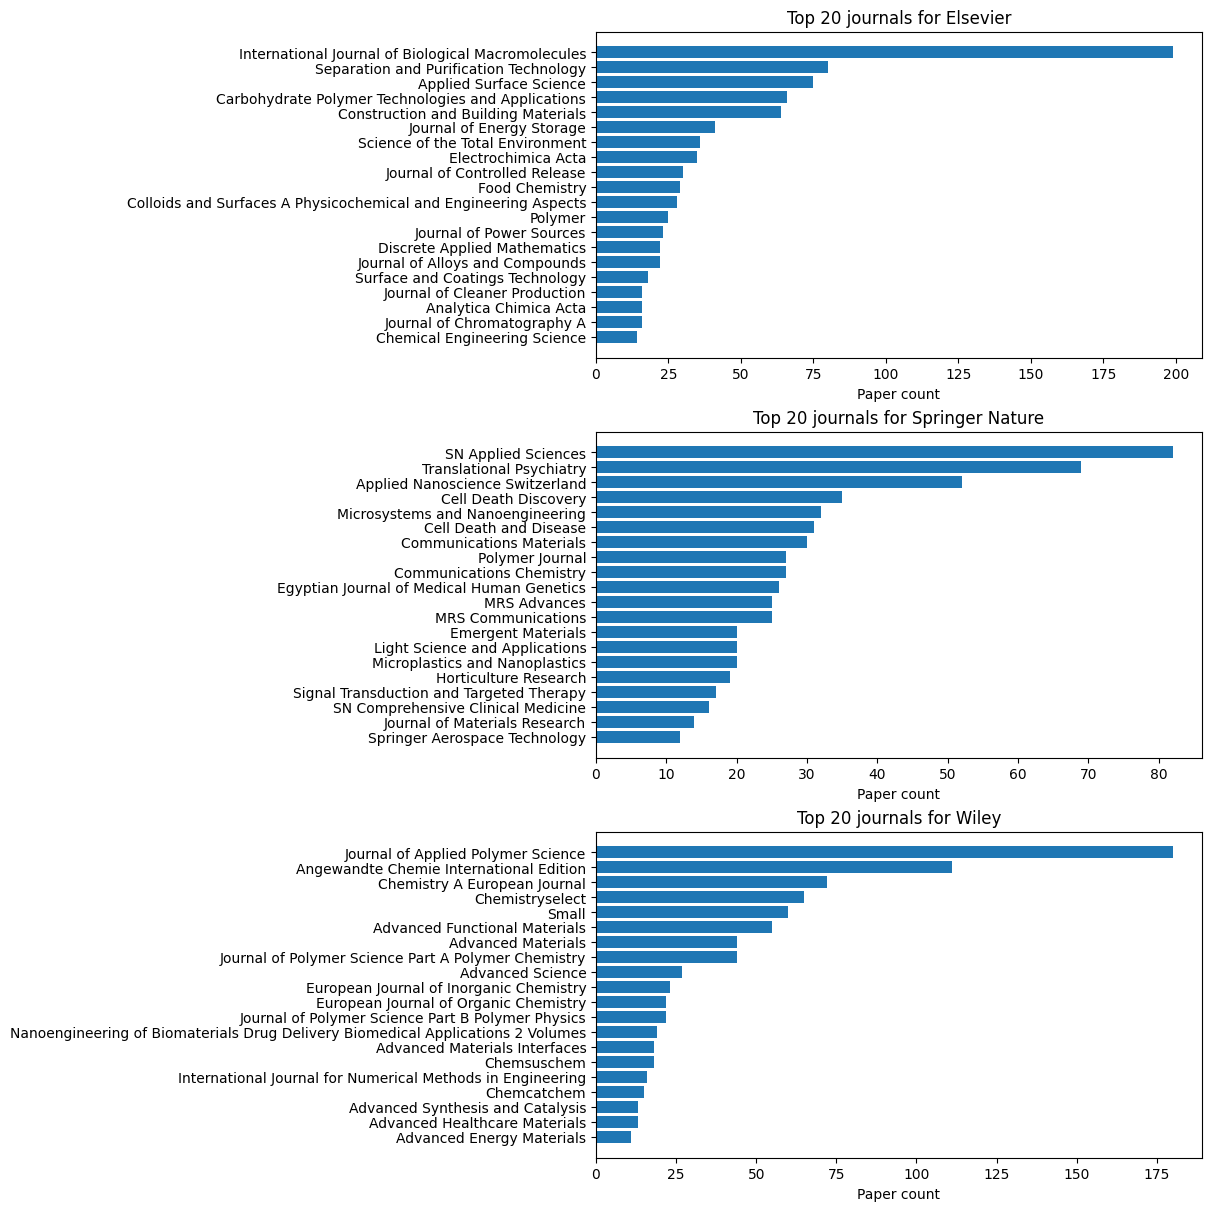

In [39]:
journal_dist = (
    df.groupby(["publisher", "journal"])
    .size()
    .reset_index(name="paper_count")
    .sort_values(["publisher", "paper_count"], ascending=[True, False])
)

top_n = 20
top_journals = journal_dist.groupby("publisher", as_index=False).head(top_n)

publishers = top_journals["publisher"].unique()
fig, axes = plt.subplots(len(publishers), 1, figsize=(12, 4 * len(publishers)), constrained_layout=True)

if len(publishers) == 1:
    axes = [axes]

for ax, pub in zip(axes, publishers):
    subset = top_journals[top_journals["publisher"] == pub].sort_values("paper_count")
    ax.barh(subset["journal"], subset["paper_count"])
    ax.set_title(f"Top {top_n} journals for {pub}")
    ax.set_xlabel("Paper count")

plt.show()

Get abstracts

In [51]:
df["abstract"] = "Not Found"
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag,abstract
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False,Not Found
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False,Not Found
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True,Not Found
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False,Not Found
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False,Not Found


In [85]:
from difflib import SequenceMatcher

def normalize_title(title: str) -> str:
    title = title.lower()

    # remove punctuation
    title = re.sub(r"[^\w\s]", " ", title)

    # collapse whitespace
    title = re.sub(r"\s+", " ", title)

    return title.strip()

def title_match(
    title1: str,
    title2: str,
    threshold: float = 0.90,
) -> bool:
    t1 = normalize_title(title1)
    t2 = normalize_title(title2)

    score = SequenceMatcher(None, t1, t2).ratio()

    return score >= threshold

In [ ]:
def get_crossref_abstract(
    doi: str | None,
    title: str | None,
    mailto: str | None = None,
    timeout: int = 30,
) -> str | None:
    """
        get
    """
    doi = str(doi).strip()

    mailto = "kevinge@chalmers.se"
    headers = {
        "User-Agent": f"abstract-fetcher/0.1 (mailto:{mailto})",
    }

    url = f"https://api.crossref.org/works/{doi}"
    response = requests.get(
        url.format(doi=doi),
        headers=headers,
        timeout=timeout,
    )

    response.raise_for_status()

    data = response.json()

    title_list = data.get("message", {}).get("title", [])
    crossref_title = title_list[0] if title_list else None
    safe_flag = False
    if crossref_title:
        if title_match(title, crossref_title):
            safe_flag = True
        else:
            print(f"[Warning]: Title Mismatch for doi: {doi}")
            print(f"Title: {title}")
            print(f"crossref: {crossref_title}")

    raw_abstract = data.get("message", {}).get("abstract")

    if not raw_abstract:
        return None, None

    # Strip JATS XML tags (e.g. <jats:p>, <jats:title>) and collapse whitespace
    # Remove <jats:title>Abstract</jats:title>
    clean_abstract = re.sub(
        r"<jats:title[^>]*>.*?</jats:title>",
        " ",
        raw_abstract,
        flags=re.I | re.S,
    )
    clean_abstract = re.sub(r"<[^>]+>", " ", clean_abstract)
    clean_abstract = re.sub(r"\s+", " ", clean_abstract).strip()

    return clean_abstract, safe_flag

In [ ]:
for idx, row in df.iterrows():

    current_abstract = row["abstract"]

    # Skip rows that already have an abstract
    if (
        pd.notna(current_abstract)
        and str(current_abstract).strip()
        and str(current_abstract).strip().lower() != "not found"
    ):
        continue

    doi = row["doi"]
    title = row["title"]

    if pd.isna(doi):
        print(f"[CHECK]: doi not in dataframe at index {idx}")
        continue

    time.sleep(0.1)  # be nice to Crossref

    try:
        abstract, safe_flag = get_crossref_abstract(
            doi=doi,
            title=title,
            mailto = "kevinge@chalmers.se"
        )

    except Exception as e:
        print(
            f"Crossref failed | DOI={doi} | "
            f"TITLE={title[:80]} | ERROR={e}"
        )
        continue

    if not abstract:
        continue

    if not safe_flag:
        continue

    df.at[idx, "abstract"] = abstract

    print("[INFO]: Abstract found")
    if idx % 100 == 0 and idx != 0:
        print(f"[INFO]: currently at idx {idx}")

[Warning]: Title Mismatch for doi: 10.1016/j.catena.2025.109504
Title: Mendeley Data
rossref: Skeletal and sedimentary structures in yardang caverns in the Mars analog, Qaidam Basin: origin and implication
Crossref failed | DOI=10.1016/j.est.2025.119087 | TITLE=Ce-V2O5/MBene composite as a multifunctional catalyst for synergistic polysulfid | ERROR=404 Client Error: Not Found for url: https://api.crossref.org/works/10.1016/j.est.2025.119087
[Warning]: Title Mismatch for doi: 10.1016/j.dam.2021.08.032
Title: Finding densest k-connected subgraphs
rossref: Finding densest <mml:math xmlns:mml="http://www.w3.org/1998/Math/MathML" display="inline" id="d1e349" altimg="si11.svg"><mml:mi>k</mml:mi></mml:math>-connected subgraphs
[Warning]: Title Mismatch for doi: 10.1016/j.dam.2021.09.009
Title: Reducing the domination number of (P3+kP2)-free graphs via one edge contraction
rossref: Reducing the domination number of <mml:math xmlns:mml="http://www.w3.org/1998/Math/MathML" display="inline" id="d

In [104]:
summary = (
    df.assign(
        abstract_found=lambda x: (
            x["abstract"].notna()
            & (x["abstract"] != "Not Found")
            & (x["abstract"].str.strip() != "")
        )
    )
    .groupby("publisher")
    .agg(
        total_papers=("publisher", "size"),
        abstracts_found=("abstract_found", "sum"),
    )
)

summary["retrieval_rate"] = (
    100 * summary["abstracts_found"] / summary["total_papers"]
).round(1)

print(summary)

                 total_papers  abstracts_found  retrieval_rate
publisher                                                     
Elsevier                 1000                0             0.0
Springer Nature          1000              448            44.8
Wiley                    1000              915            91.5


In [ ]:
output_path = os.path.join("..", "data", f"papers_post_crossref.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

Use Scopus

In [107]:
output_path = os.path.join("..", "data", f"papers_post_crossref.csv")
df = pd.read_csv(
    output_path, sep="\t"
)

In [108]:
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag,abstract
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False,Not Found
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False,Not Found
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True,Not Found
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False,Not Found
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False,Not Found


In [131]:
from pybliometrics.scopus import AbstractRetrieval


def get_scopus_abstract(
    doi: str | None,
) -> str | None:

    if not doi:
        return None

    doi = str(doi).strip()

    try:
        record = AbstractRetrieval(
            doi,
            id_type="doi",
            view="META_ABS",
        )

        # Prefer abstract
        abstract = record.abstract

        # Fallback to description if abstract missing
        if not abstract:
            abstract = getattr(record, "description", None)

        if not abstract:
            print(
                f"No abstract/description found for DOI: {doi}"
            )
            return None

        abstract = " ".join(str(abstract).split())

        return abstract

    except Exception as e:
        print(
            f"Scopus AbstractRetrieval failed | DOI={doi} | "
            f"ERROR={type(e).__name__}: {e}"
        )
        return None

In [132]:
for idx, row in df.iterrows():
    if idx % 100 == 0 and idx != 0:
        print(f"[INFO]: currently at idx {idx}")

    current_abstract = row["abstract"]

    # Skip rows that already have an abstract
    if (
        pd.notna(current_abstract)
        and str(current_abstract).strip()
        and str(current_abstract).strip().lower() != "not found"
    ):
        continue

    doi = row["doi"]

    if pd.isna(doi):
        print(f"[CHECK]: doi not in dataframe at index {idx}")
        continue

    abstract = get_scopus_abstract(
        doi=doi
    )
    time.sleep(0.2)  # respect api rate limits

    if not abstract:
        continue

    df.at[idx, "abstract"] = abstract

    print("[INFO]: Abstract found")

[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abs

In [133]:
summary = (
    df.assign(
        abstract_found=lambda x: (
            x["abstract"].notna()
            & (x["abstract"] != "Not Found")
            & (x["abstract"].str.strip() != "")
        )
    )
    .groupby("publisher")
    .agg(
        total_papers=("publisher", "size"),
        abstracts_found=("abstract_found", "sum"),
    )
)

summary["retrieval_rate"] = (
    100 * summary["abstracts_found"] / summary["total_papers"]
).round(1)

print(summary)

                 total_papers  abstracts_found  retrieval_rate
publisher                                                     
Elsevier                 1000              996            99.6
Springer Nature          1000              987            98.7
Wiley                    1000              995            99.5


In [134]:
output_path = os.path.join("..", "data", f"papers_post_scopus.csv")

df.to_csv(
    output_path,
    sep="\t",
    index=False,
    encoding="utf-8",
)

In [106]:
# Publisher TDMs

Building a classifier